In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load CSV
df = pd.read_csv("neutrality_test_24hpi_Dox.csv")

# Axes
x = np.log2(df["q_hat_recipient_center"] / df["p_donor"])
y = -np.log10(df["qval_FDR"])

# Threshold line: p = 2.51e-06  ->  y = -log10(p)
p_thresh = 2.51e-06
y_thresh = -np.log10(p_thresh)

# Indices of 10 smallest and 10 largest x values
idx_small = x.nsmallest(10).index
idx_large = x.nlargest(10).index
idx_highlight = idx_small.union(idx_large)

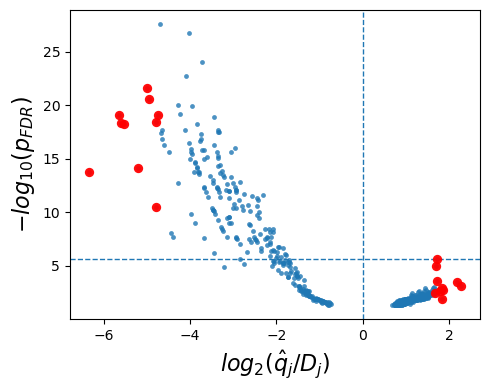

In [3]:
# Plot
plt.figure(figsize=(5, 4))
plt.scatter(x, y, s=12, alpha=0.8, linewidths=0)

plt.axvline(0, linestyle="--", linewidth=1)
plt.axhline(y_thresh, linestyle="--", linewidth=1)

# highlighted points
plt.scatter(x.loc[idx_highlight], y.loc[idx_highlight], s=45, color="red", alpha=0.95, linewidths=0, zorder=3)

plt.xlabel("$log_2(\hat{q}_j/D_j)$", fontsize = 16)
plt.ylabel("$-log_{10}(p_{FDR})$", fontsize = 16)

plt.tight_layout()
plt.show()